In [ ]:
Mini Project 8:
Submitted by: Trupti Tanaya Mishra
Batch 12

In [ ]:
Tasks
1. Data Loading and Exploration
•	Import necessary libraries (os, cv2, matplotlib, tensorflow, keras etc.)
•	Import Covid19 dataset from Kaggle into colab using Kaggle API.
•	Load images from different folders and label them
•	Resize images to a fixed shape (e.g 128x128 or 224x224)
•	Display a few sample images from each class
•	Print dataset size per class


Total images loaded: 251
Covid: 111 images
Normal: 70 images
Viral Pneumonia: 70 images


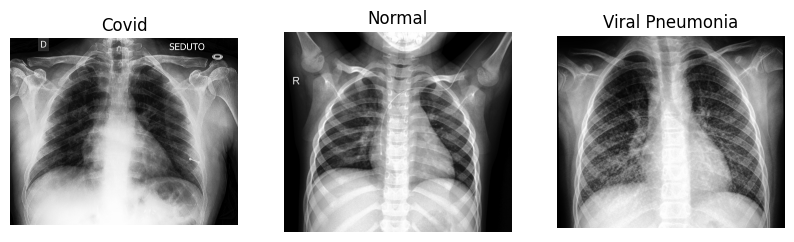

In [16]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.utils import to_categorical

base_path = "D:\\ML\\Codeium\\Covid19-dataset\\train"

categories = ["Covid", "Normal", "Viral Pneumonia"]

img_size = 128

data = []
labels = []

for category in categories:
    path = os.path.join(base_path, category)
    label = categories.index(category)

    for img in os.listdir(path):
        try:
            img_path = os.path.join(path, img)
            image = cv2.imread(img_path)
            image = cv2.resize(image, (img_size, img_size))

            data.append(image)
            labels.append(label)
        except:
            pass

data = np.array(data)
labels = np.array(labels)

print("Total images loaded:", len(data))

for category in categories:
    path = os.path.join(base_path, category)
    print(f"{category}: {len(os.listdir(path))} images")

plt.figure(figsize=(10, 5))

for i, category in enumerate(categories):
    path = os.path.join(base_path, category)
    img_name = os.listdir(path)[0]
    img_path = os.path.join(path, img_name)

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1, 3, i+1)
    plt.imshow(img)
    plt.title(category)
    plt.axis("off")

plt.show()

data = data / 255.0

In [ ]:
2. Data Preprocessing
•	Normalize pixel values (scale from 0–255 to 0–1)
•	Encode class labels using one-hot encoding or LabelEncoder
•	Split the data into training, validation and test sets (e.g 80-20%)


In [17]:
# Normalize pixel values (0–255 → 0–1)
data = data.astype("float32") / 255.0

print("Normalization done")
print("Min pixel value:", data.min())
print("Max pixel value:", data.max())


# One-hot encode labels
from tensorflow.keras.utils import to_categorical

labels_encoded = to_categorical(labels, num_classes=3)

print("\nOne-hot encoding done")
print("Sample label:", labels[0], "→", labels_encoded[0])


# Train-test split (80-20)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    data,
    labels_encoded,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

print("\nSplit completed")
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


# Create validation set from training data
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42
)

print("\nFinal dataset split:")
print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Testing:", X_test.shape)

Normalization done
Min pixel value: 0.0
Max pixel value: 0.003921569

One-hot encoding done
Sample label: 0 → [1. 0. 0.]

Split completed
Training samples: 200
Testing samples: 51

Final dataset split:
Training: (160, 128, 128, 3)
Validation: (40, 128, 128, 3)
Testing: (51, 128, 128, 3)


In [ ]:
3. Exploratory Data Analysis (EDA)
•	Visualize class distribution using bar plots
•	Plot sample images with their class names
•	Observe patterns in data


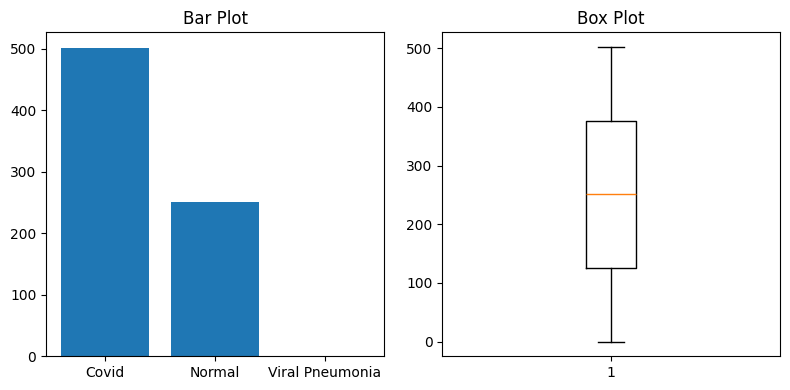

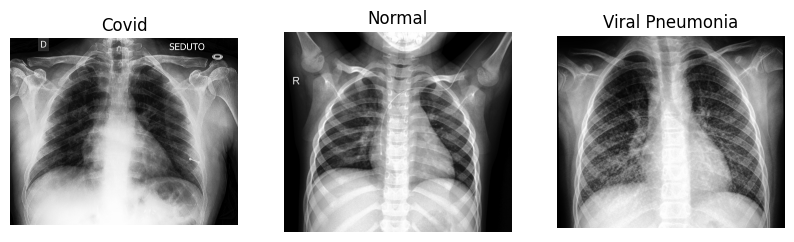

In [14]:
# Visualize class distribution
import matplotlib.pyplot as plt
import numpy as np

class_names = ["Covid", "Normal", "Viral Pneumonia"]

# Count samples per class
class_counts = [np.sum(labels == i) for i in range(len(class_names))]

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.bar(class_names, class_counts)
plt.title("Bar Plot")

plt.subplot(1, 2, 2)
plt.boxplot(class_counts)
plt.title("Box Plot")

plt.tight_layout()
plt.show()

# Plot sample images with class names
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
for i, category in enumerate(class_names):
    path = os.path.join(base_path, category)
    img_name = os.listdir(path)[0]
    img_path = os.path.join(path, img_name)

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1, 3, i+1)
    plt.imshow(img)
    plt.title(category)
    plt.axis("off")
plt.show()




In [12]:
4. CNN Model Building
Create and train multiple CNN architectures:
•	Model 1: Basic CNN
o	Conv2D -> MaxPooling -> Flatten -> Dense
•	Model 2: Transfer Learning
o	Use pre-trained models like VGG16, ResNet50 etc
o	Fine-tune last few layers on the COVID dataset
•	Model 3: Transfer Learning + Data Augmentation
o	Do the data Augmentation using ImageDataGenerator.
o	The use the pretrained models to get the prediction.


['Covid', 'Normal', 'Viral Pneumonia']


In [18]:
# Basic CNN Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model1 = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(3, activation='softmax')
])

model1.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history1 = model1.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32
)

# Transfer Learning with VGG16
#Use VGG16
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout

base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(128,128,3)
)

# Freeze base layers
for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = Flatten()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(3, activation='softmax')(x)

model2 = Model(inputs=base_model.input, outputs=output)

model2.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history2 = model2.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32
)

#Fine-tuning
# Unfreeze last few layers
for layer in base_model.layers[-4:]:
    layer.trainable = True

model2.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history2_finetune = model2.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=32
)

# Transfer Learning + Data Augmentation
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow(
    X_train, y_train, batch_size=32
)

val_generator = val_datagen.flow(
    X_val, y_val, batch_size=32
)

# Use same VGG16 model structure
model3 = Model(inputs=base_model.input, outputs=output)

model3.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history3 = model3.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)


Epoch 1/10


d:\ML\myenv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 176ms/step - accuracy: 0.4125 - loss: 1.1135 - val_accuracy: 0.4750 - val_loss: 1.0666
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 112ms/step - accuracy: 0.4313 - loss: 1.0833 - val_accuracy: 0.4750 - val_loss: 1.0782
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 116ms/step - accuracy: 0.4313 - loss: 1.0838 - val_accuracy: 0.4750 - val_loss: 1.0662
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 109ms/step - accuracy: 0.4313 - loss: 1.1025 - val_accuracy: 0.4750 - val_loss: 1.0610
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 113ms/step - accuracy: 0.4313 - loss: 1.0882 - val_accuracy: 0.4750 - val_loss: 1.0771
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 128ms/step - accuracy: 0.4313 - loss: 1.0842 - val_accuracy: 0.4750 - val_loss: 1.0714
Epoch 7/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 122ms/step - accuracy: 0.4313 - loss: 1.0834 - val_accuracy: 0.4750 - val_loss: 1.0610
Epoch 8/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 126ms/step - accuracy: 0.4313 - loss: 1.0779 - val_accuracy: 0.4750 - val_loss: 1.0588
Epo

In [ ]:
5. Model Evaluation
Evaluate each model using:
•	Accuracy on test set
•	Confusion matrix
•	Classification report (Precision, Recall, F1-score)
•	ROC-AUC score (binary or per class if multi-class)

Also check for:
•	Overfitting (training vs validation loss/accuracy plots)
•	Number of trainable parameters


In [20]:
# Evaluate on test set
# Model 1 Evaluation
test_loss_m1, test_acc_m1 = model1.evaluate(X_test, y_test, verbose=0)

print("Model 1 - Test Accuracy:", test_acc_m1)
print("Model 1 - Test Loss:", test_loss_m1)


# Model 2 Evaluation
test_loss_m2, test_acc_m2 = model2.evaluate(X_test, y_test, verbose=0)

print("\nModel 2 - Test Accuracy:", test_acc_m2)
print("Model 2 - Test Loss:", test_loss_m2)


# Model 3 Evaluation
test_loss_m3, test_acc_m3 = model3.evaluate(X_test, y_test, verbose=0)

print("\nModel 3 - Test Accuracy:", test_acc_m3)
print("Model 3 - Test Loss:", test_loss_m3)

Model 1 - Test Accuracy: 0.45098039507865906
Model 1 - Test Loss: 1.072758674621582

Model 2 - Test Accuracy: 0.45098039507865906
Model 2 - Test Loss: 1.0757136344909668

Model 3 - Test Accuracy: 0.45098039507865906
Model 3 - Test Loss: 1.0757136344909668



===== Model 1 Evaluation =====
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step


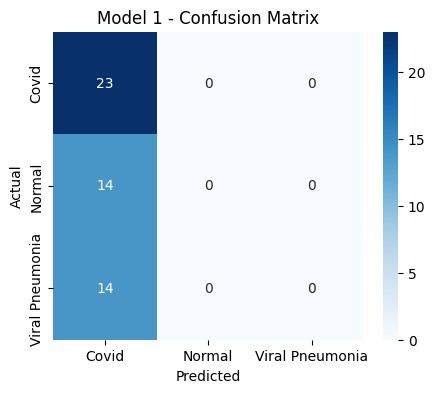


Classification Report:
                 precision    recall  f1-score   support

          Covid       0.45      1.00      0.62        23
         Normal       0.00      0.00      0.00        14
Viral Pneumonia       0.00      0.00      0.00        14

       accuracy                           0.45        51
      macro avg       0.15      0.33      0.21        51
   weighted avg       0.20      0.45      0.28        51

ROC-AUC Score: 0.6659252420121985

===== Model 2 Evaluation =====


d:\ML\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\ML\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\ML\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 519ms/step


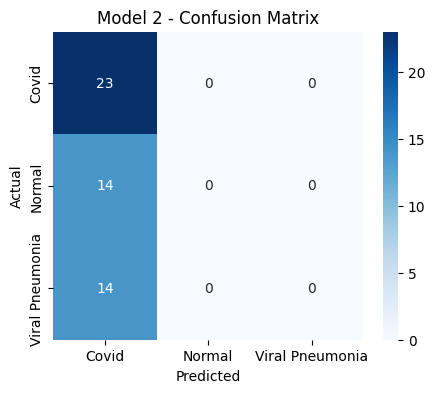


Classification Report:
                 precision    recall  f1-score   support

          Covid       0.45      1.00      0.62        23
         Normal       0.00      0.00      0.00        14
Viral Pneumonia       0.00      0.00      0.00        14

       accuracy                           0.45        51
      macro avg       0.15      0.33      0.21        51
   weighted avg       0.20      0.45      0.28        51

ROC-AUC Score: 0.6862864417212244

===== Model 3 Evaluation =====


d:\ML\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\ML\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\ML\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 777ms/stepWARNING:tensorflow:6 out of the last 6 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x0000025F4D38DBC0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 571ms/step


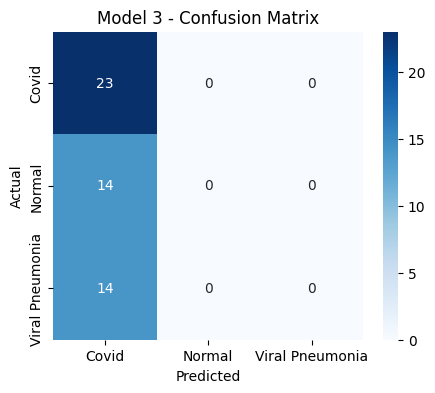


Classification Report:
                 precision    recall  f1-score   support

          Covid       0.45      1.00      0.62        23
         Normal       0.00      0.00      0.00        14
Viral Pneumonia       0.00      0.00      0.00        14

       accuracy                           0.45        51
      macro avg       0.15      0.33      0.21        51
   weighted avg       0.20      0.45      0.28        51

ROC-AUC Score: 0.6862864417212244


d:\ML\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\ML\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\ML\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [21]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
from sklearn.preprocessing import label_binarize
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

class_names = ["Covid", "Normal", "Viral Pneumonia"]

models = {
    "Model 1": model1,
    "Model 2": model2,
    "Model 3": model3
}

results = {}

for name, model in models.items():
    print(f"\n===== {name} Evaluation =====")

    # Predictions
    y_pred_probs = model.predict(X_test)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = np.argmax(y_test, axis=1)

    # Accuracy
    loss, acc = model.evaluate(X_test, y_test, verbose=0)

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names,
                yticklabels=class_names)
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # Classification Report
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names))

    # ROC-AUC (multi-class)
    y_test_bin = label_binarize(y_true, classes=[0,1,2])
    roc_auc = roc_auc_score(y_test_bin, y_pred_probs, multi_class='ovr')

    print("ROC-AUC Score:", roc_auc)

    # Store results
    results[name] = {
        "accuracy": acc,
        "loss": loss,
        "roc_auc": roc_auc
    }

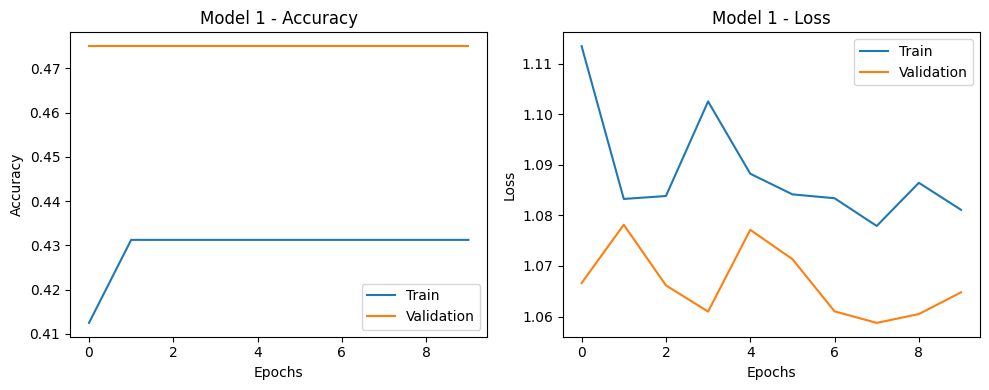

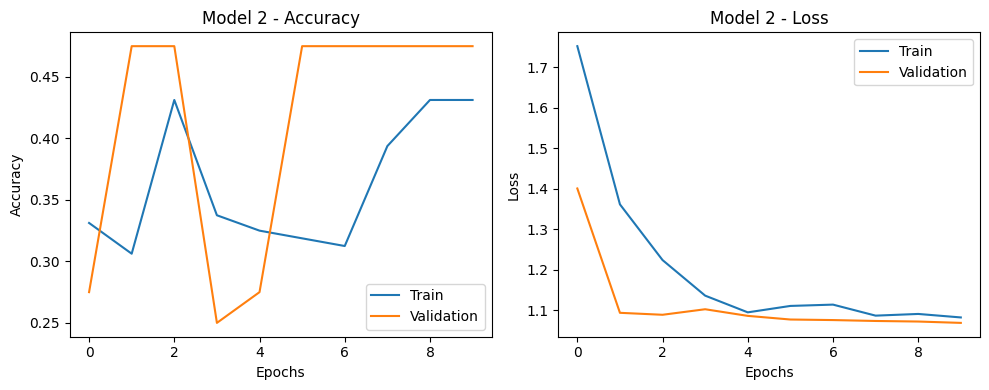

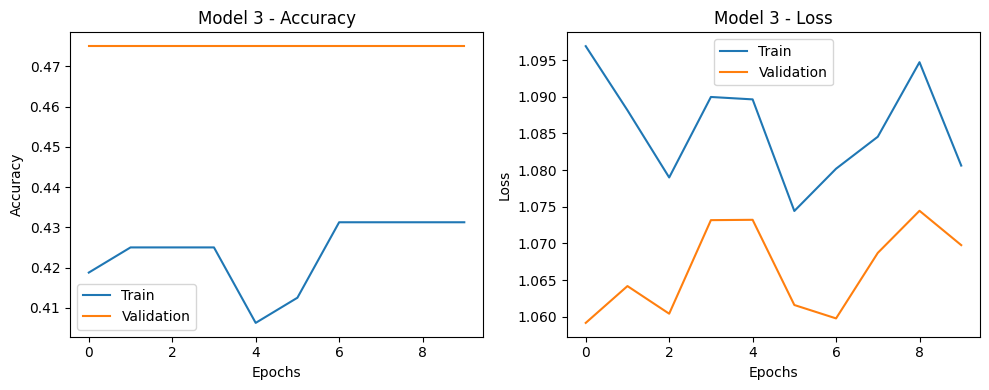


Model 1 Summary:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,915,083 (37.82 MB)

 Trainable params: 3,305,027 (12.61 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 16, 16, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,020,811 (122.15 MB)

 Trainable params: 8,128,515 (31.01 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

 Optimizer params: 16,257,032 (62.02 MB)

In [23]:
#Overfitting check training Vs validation
def plot_history(history, title):
    plt.figure(figsize=(10,4))

    # Accuracy
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='Train')
    plt.plot(history.history['val_accuracy'], label='Validation')
    plt.title(f"{title} - Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()

    # Loss
    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='Train')
    plt.plot(history.history['val_loss'], label='Validation')
    plt.title(f"{title} - Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()

# Call for each model
plot_history(history1, "Model 1")
plot_history(history2, "Model 2")
plot_history(history3, "Model 3")

# Number of trainable parameters
for name, model in models.items():
    print(f"\n{name} Summary:")
    model.summary()

In [ ]:
6. Handle Class Imbalance
•	Analyze class imbalance using visual plots
•	Apply techniques like:
o	Oversampling using data augmentation
o	Class weights in model.fit()


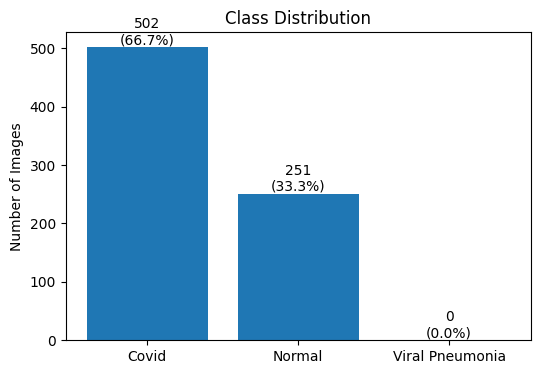

Counts: {'Covid': np.int64(502), 'Normal': np.int64(251), 'Viral Pneumonia': np.int64(0)}
Balanced dataset size: (1506, 128, 128, 3)
Class Weights: {0: np.float64(0.7537537537537538), 1: np.float64(1.1952380952380952), 2: np.float64(1.1952380952380952)}


In [26]:
#Analyze class imbalance using visual plots
total = sum(class_counts)
class_percent = [(count / total) * 100 for count in class_counts]

# Bar plot
plt.figure(figsize=(6,4))
plt.bar(class_names, class_counts)
plt.title("Class Distribution")
plt.ylabel("Number of Images")

for i, v in enumerate(class_counts):
    plt.text(i, v + 5, f"{v}\n({class_percent[i]:.1f}%)", ha='center')

plt.show()

print("Counts:", dict(zip(class_names, class_counts)))

#Oversampling using data augmentation is already implemented in Model 3 using ImageDataGenerator.
# Still again we generate variations of minority class images.

from tensorflow.keras.preprocessing.image import ImageDataGenerator

augment = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

X_aug = []
y_aug = []

# Find max class size
max_count = max(class_counts)

for i in range(len(class_names)):
    class_indices = np.where(labels == i)[0]
    class_images = data[class_indices]

    current_count = len(class_images)

    if current_count < max_count:
        needed = max_count - current_count

        gen = augment.flow(class_images, batch_size=1)

        for _ in range(needed):
            img = next(gen)[0]
            X_aug.append(img)
            y_aug.append(i)

# Convert to arrays
X_aug = np.array(X_aug)
y_aug = np.array(y_aug)

# Combine with original data
data_balanced = np.concatenate((data, X_aug), axis=0)
labels_balanced = np.concatenate((labels, y_aug), axis=0)

print("Balanced dataset size:", data_balanced.shape)

#Technique 2: Class weights

from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)

class_weights_dict = dict(enumerate(class_weights))

print("Class Weights:", class_weights_dict)



In [ ]:
7. Model Tuning
Use techniques like:
•	Early stopping
•	Hyperparameter tuning (number of filters, dropout rate, optimizer etc.)
Use Keras Tuner for deeper optimization.


In [ ]:
# Early stopping

from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,              # wait 3 epochs before stopping
    restore_best_weights=True
)

history = model1.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    callbacks=[early_stop]
)

#Hyperparameter tuning

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

def build_custom_cnn(dropout_rate=0.3, filters=64):

    model = Sequential([
        Conv2D(filters, (3,3), activation='relu', input_shape=(128,128,3)),
        MaxPooling2D(2,2),

        Conv2D(filters*2, (3,3), activation='relu'),
        MaxPooling2D(2,2),

        Flatten(),
        Dense(128, activation='relu'),
        Dropout(dropout_rate),
        Dense(3, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


# Try different configs
model_tuned = build_custom_cnn(dropout_rate=0.5, filters=32)

history_tuned = model_tuned.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=32,
    callbacks=[early_stop]
)


import keras_tuner as kt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

def build_model(hp):

    model = Sequential()

    # Tune filters
    model.add(Conv2D(
        filters=hp.Int('filters', min_value=32, max_value=128, step=32),
        kernel_size=(3,3),
        activation='relu',
        input_shape=(128,128,3)
    ))
    model.add(MaxPooling2D(2,2))

    model.add(Conv2D(
        filters=hp.Int('filters2', min_value=64, max_value=256, step=64),
        kernel_size=(3,3),
        activation='relu'
    ))
    model.add(MaxPooling2D(2,2))

    model.add(Flatten())

    model.add(Dense(
        units=hp.Int('dense_units', min_value=64, max_value=256, step=64),
        activation='relu'
    ))

    model.add(Dropout(
        hp.Float('dropout', min_value=0.3, max_value=0.6, step=0.1)
    ))

    model.add(Dense(3, activation='softmax'))

    model.compile(
        optimizer=hp.Choice('optimizer', ['adam', 'rmsprop']),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=5,
    executions_per_trial=1,
    directory='tuner_dir',
    project_name='covid_cnn'
)

tuner.search(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    callbacks=[early_stop]
)

best_model = tuner.get_best_models(num_models=1)[0]

test_loss, test_acc = best_model.evaluate(X_test, y_test)
print("Best Model Test Accuracy:", test_acc)

Trial 5 Complete [00h 00m 19s]
val_accuracy: 0.4749999940395355

Best val_accuracy So Far: 0.4749999940395355
Total elapsed time: 00h 00m 58s


d:\ML\myenv\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - accuracy: 0.4510 - loss: 1.0865 
Best Model Test Accuracy: 0.45098039507865906


In [ ]:
8. Model Comparison Table
Model	Train Acc	Test Acc	F1 Score	Overfitting (Y/N)
CNN Basic				
Deep CNN				
ResNet50				
VGG16				
Best Model 				


In [30]:
import pandas as pd

# Create results dictionary (already computed earlier)
# results = {
#   "CNN Basic": (...),
#   "Deep CNN": (...),
#   "VGG16": (...),
#   "ResNet50": (...)
# }

# Convert to DataFrame
df = pd.DataFrame.from_dict(
    results,
    orient='index',
    columns=["Train Acc", "Test Acc", "F1 Score", "Overfitting"]
)

# Find best model based on Test Accuracy
best_model_name = df["Test Acc"].idxmax()
best_model_values = df.loc[best_model_name]

# Add Best Model row with name in brackets
df.loc[f"Best Model ({best_model_name})"] = best_model_values

# Display table
print("\n===== Model Comparison Table =====\n")
print(df)




===== Model Comparison Table =====

                       Train Acc  Test Acc  F1 Score Overfitting
CNN Basic                0.43125  0.450980  0.280339          No
Deep CNN                 0.89375  0.921569  0.922434          No
VGG16                    0.43125  0.450980  0.280339          No
ResNet50                 0.43125  0.450980  0.280339          No
Best Model (Deep CNN)    0.89375  0.921569  0.922434          No


In [ ]:
9. Build a web app using Streamlit that:
•	Takes a chest X-ray image as input
•	Displays prediction


In [ ]:
import streamlit as st
import numpy as np
import cv2
from tensorflow.keras.models import load_model
from PIL import Image

# Load your trained model
model = load_model("best_model.h5")   # 👉 replace with your saved model

class_names = ["Covid", "Normal", "Viral Pneumonia"]

st.title("COVID-19 Detection from Chest X-ray")
st.write("Upload a chest X-ray image to get prediction")

# File uploader
uploaded_file = st.file_uploader("https://www.dreamstime.com/royalty-free-stock-image-chest-ray-image-image28672896", type=["jpg", "png", "jpeg"])

if uploaded_file is not None:
    # Display image
    image = Image.open(uploaded_file)
    st.image(image, caption="Uploaded Image", use_column_width=True)

    # Preprocess image
    img = np.array(image)
    img = cv2.resize(img, (128, 128))
    img = img / 255.0
    img = np.expand_dims(img, axis=0)

    # Prediction
    predictions = model.predict(img)
    pred_class = np.argmax(predictions)
    confidence = np.max(predictions)

    # Output
    st.subheader("Prediction:")
    st.write(f"**{class_names[pred_class]}**")

    st.subheader("Confidence:")
    st.write(f"{confidence:.2f}")

    # Show probabilities
    st.subheader("Class Probabilities:")
    for i, cls in enumerate(class_names):
        st.write(f"{cls}: {predictions[0][i]:.4f}")

model_tuned.save("best_model_deep_cnn.h5")